### DecisionTree (의사 결정 나무)
- parameter
    - criterion
        - 분류 
            - 기본값 : gini
            - entropy : 성능 향상, 속도가 느려진다
            - log_loss : 확률적 분류
        - 회귀
            - 기본값 : squared_error(MSE)
            - absolute_error : MAE
            - friedman_mes : 분산 감소 기반
    - spliter
        - 기본값 : best
        - 분할 시 feature(컬럼) 선택 방식
        - best
            - 가장 좋은 feature를 선택 
        - random
            - 무작위 feature를 선택(다양성을 올리기 위함 / 여러 학습을 통한 예측( 앙상블 ) )
    - max_depth
        - 기본값 : None
        - 트리의 최대 깊이 제한 
        - None인 경우 Leaf까지 계속 분할 -> 과적합 위험 
    - min_samples_split
        - 기본값 : 2
        - 노드를 분할하기 위한 최소한의 샘플 개수 지정
    - min_samples_leaf
        - 기본값 : 1
        - Leaf 노드가 되기 위한 최소 샘플 수 
    - max_features
        - 기본값 : None
        - 최적으로 분할 시 고려할 feature 개수
        - None
            - 모든 feature 사용
        - sqrt
            - feature의 개수에서 루트를 입혀서 사용
        - log2
            - feature의 개수에서 log2를 입혀서 사용
        - 숫자형태로 고정된 값을 사용 가능
    - min_impurity_decrease
        - 기본값 : 0.0
        - 불순도 감소량이 해당 매개변수의 인자값 이상일때만 데이터 분할 수행
    - ccp_alpha
        - 기본값 : 0.0
        - 비용-복잡도 가지치기 매개변수 
        - 값이 커지는 경우 트리의 단순화
- 속성 
    - tree_
        - 트리 구조에 대한 상세 객체 
    - classes_
        - 분류 분제에서 클래스의 목록(정답 리스트)
    - n_classes_
        - 클래스의 개수
    - n_features_in_
        - 입력되는 데이터의 feature 개수
    - feture_importances_
        - 각 feature들의 중요도 ( 중요도들의 합은 1 )
- 메서드
    - fit()
        - 모델 학습 
    - predict()
        - 학습된 모델로 예측
    - score()
        - 분류에서는 정확도 
        - 회귀에서는 R2 Score
    - predict_proba()
        - 분류에서만 사용하는 함수 
        - 각 클래스별 예측 확률

In [37]:
import matplotlib.pyplot as plt 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, recall_score, f1_score, \
    confusion_matrix, precision_score

In [38]:
iris = pd.read_csv("../csv/iris.csv")

In [39]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.drop('species', axis=1), 
    iris['species'], 
    test_size = 0.2, 
    random_state=42, 
    stratify=iris['species']
)

In [41]:
# max_depth 5, 3, 1을 기준으로 3개의 모델을 생성 
# score(X_train, y_train)함수를 이용해서 학습된 데이터에서 정확도를 확인 
# X_test를 이용하여 예측 -> f1_score를 이용하여 모델의 성능을 확인 
clf_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_3 = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_1 = DecisionTreeClassifier(max_depth=1, random_state=42)

In [42]:
clf_5.fit(X_train, y_train)
clf_3.fit(X_train, y_train)
clf_1.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [43]:
# 각각의 socre() 확인 
print(clf_5.score(X_train, y_train))
print(clf_3.score(X_train, y_train))
print(clf_1.score(X_train, y_train))

1.0
0.9833333333333333
0.6666666666666666


In [44]:
pred_5 = clf_5.predict(X_test)
pred_3 = clf_3.predict(X_test)
pred_1 = clf_1.predict(X_test)

In [45]:
print(f1_score(y_test, pred_5, average='micro'))
print(f1_score(y_test, pred_3, average='micro'))
print(f1_score(y_test, pred_1, average='micro'))

0.9333333333333333
0.9666666666666667
0.6666666666666666


In [62]:
# min_samples_split = 40 모델을 설정 
clf = DecisionTreeClassifier(
    max_depth=3, 
    random_state=42, 
    min_samples_split=40
)

In [63]:
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",40
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [64]:
# clf_3, clf plot_tree를 이용하여 시각화 확인 
feature_names = X_train.columns
class_names = y_train.unique()

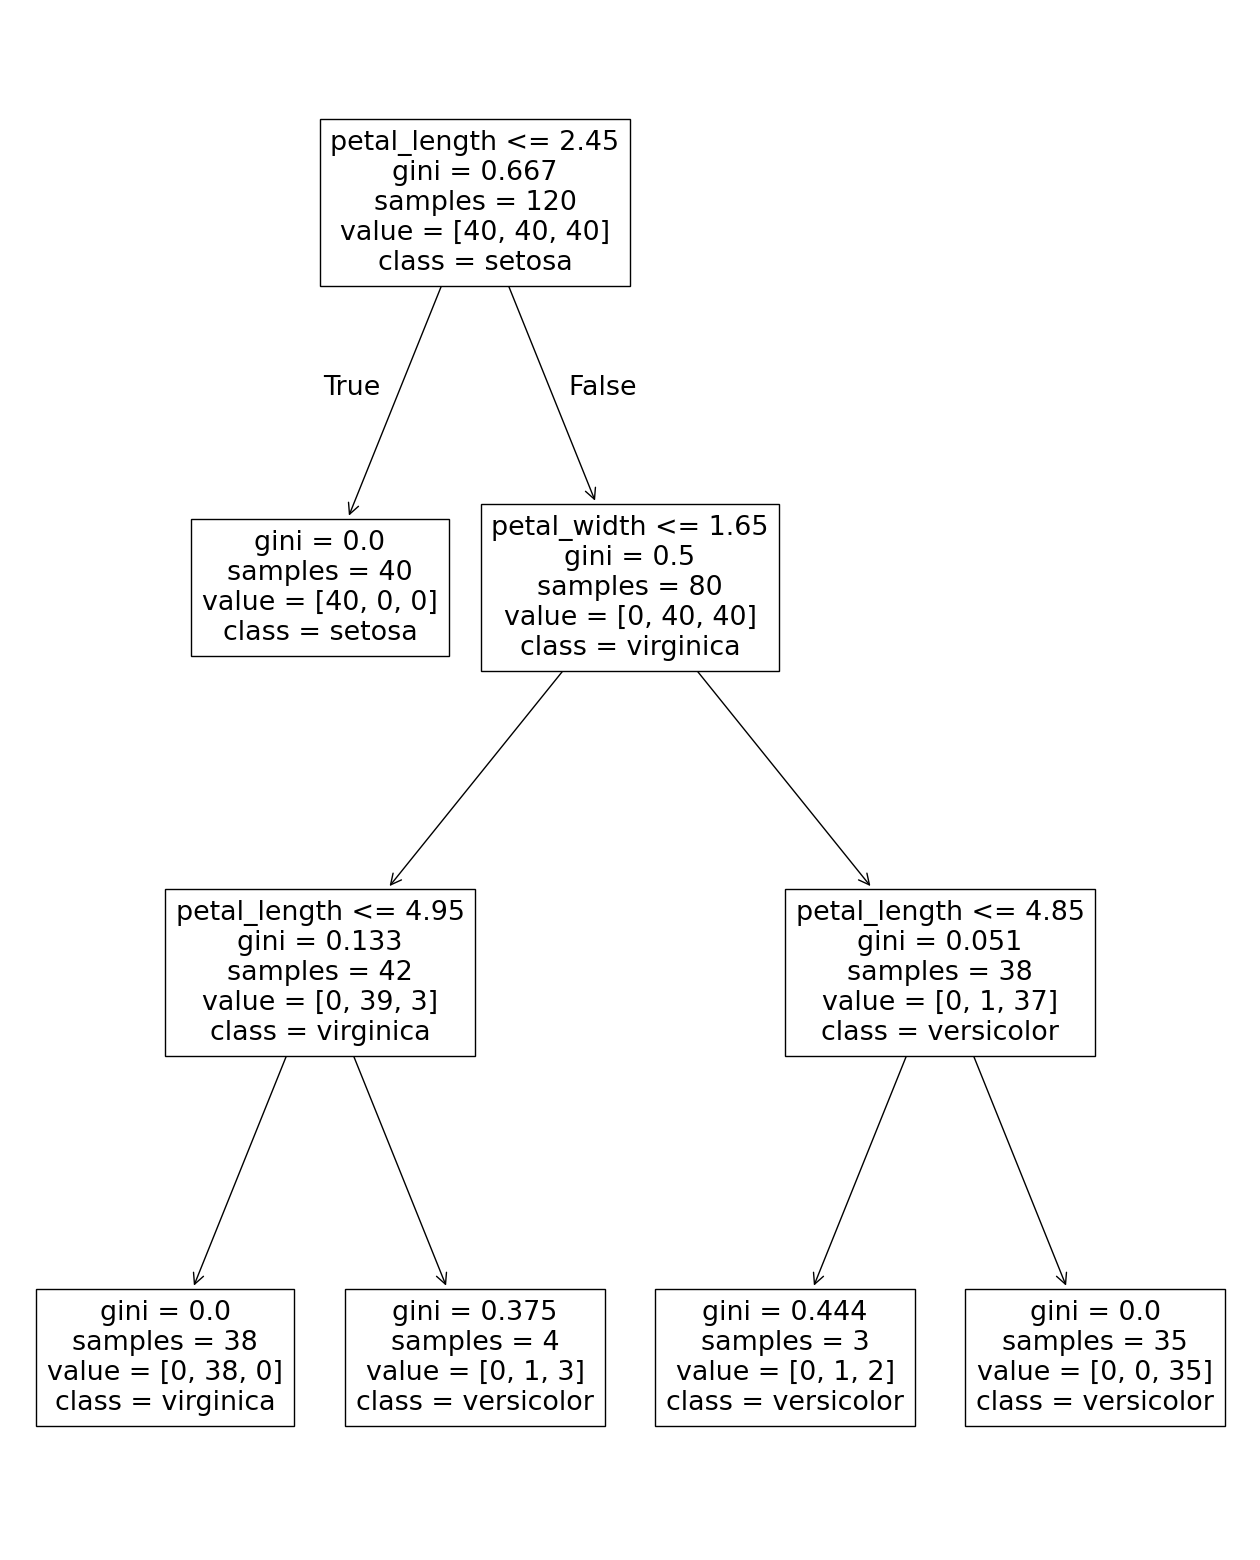

In [65]:
plt.figure(figsize=(16, 20))
plot_tree(
    clf_3, 
    feature_names= feature_names, 
    class_names=class_names
)
plt.show()

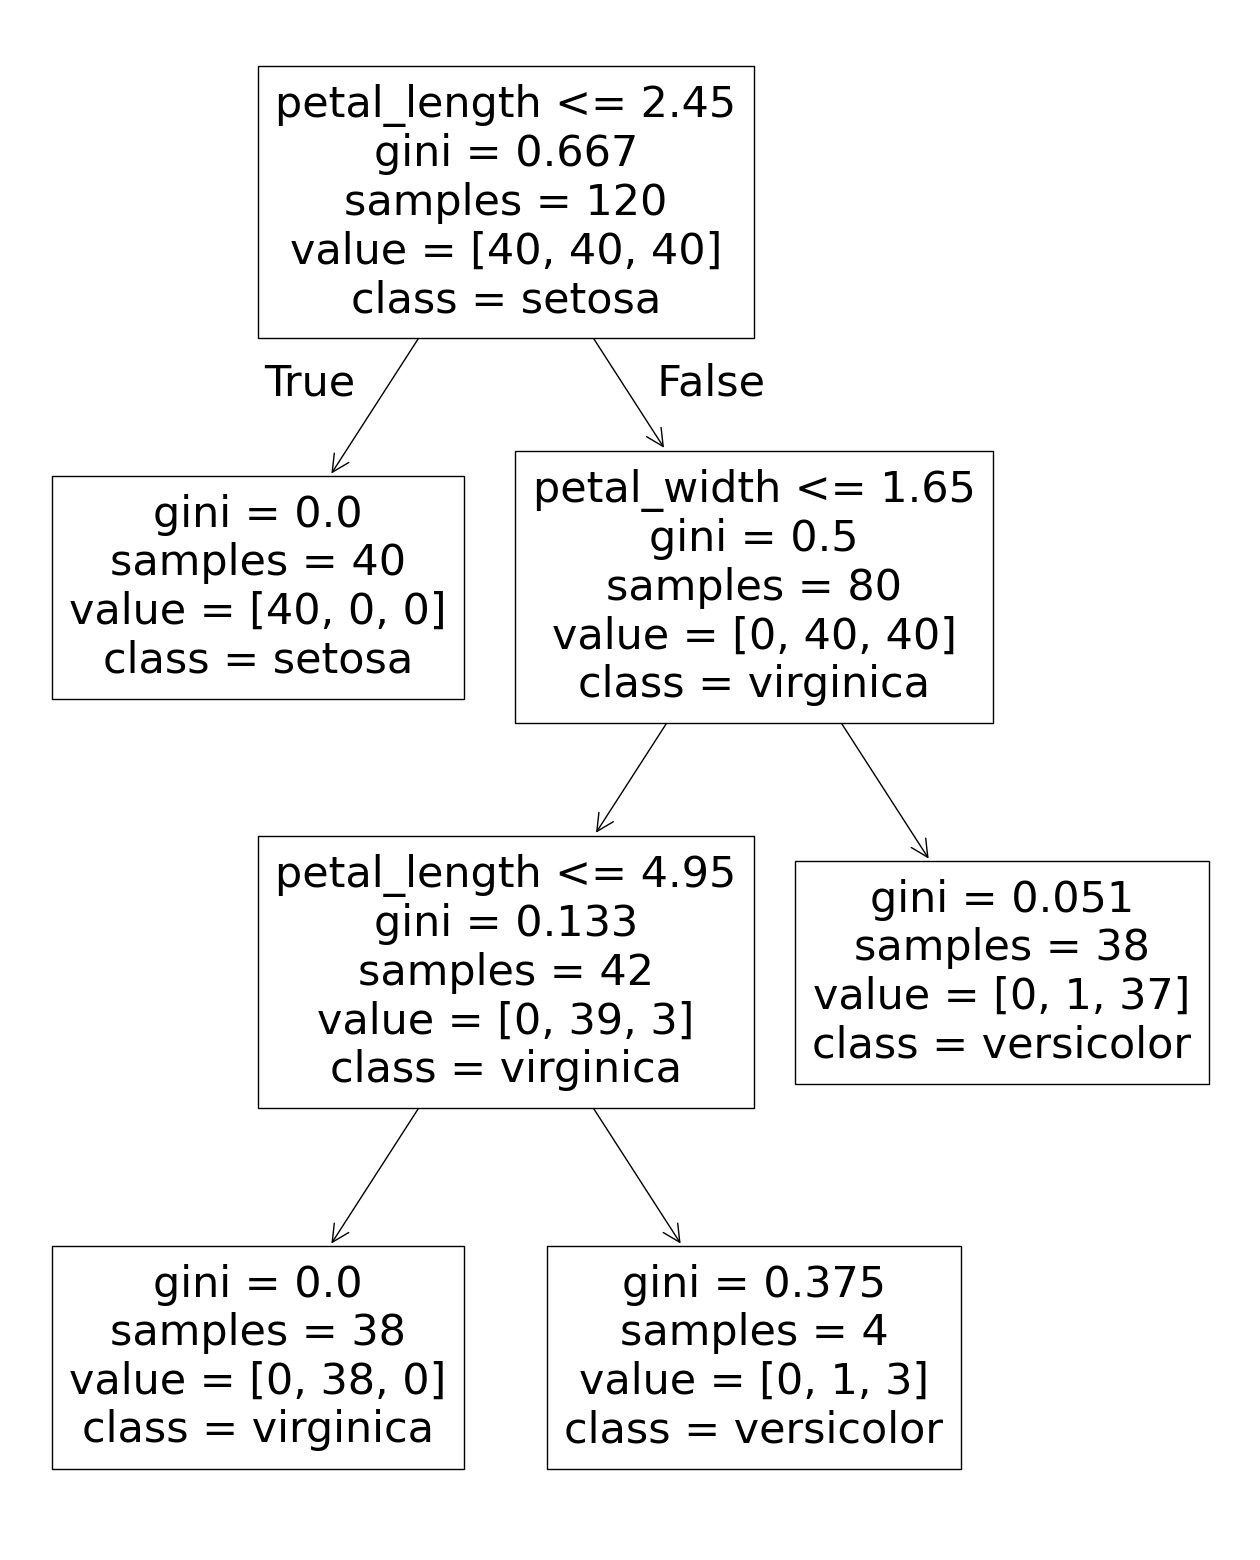

In [66]:
plt.figure(figsize=(16, 20))
plot_tree(
    clf, 
    feature_names= feature_names, 
    class_names=class_names
)
plt.show()

In [67]:
pred = clf.predict(X_test)

In [68]:
print(f1_score(y_test, pred, average='micro'))

0.9666666666666667


In [69]:
# data 폴더에서 diabetes.csv 파일 로드 
df = pd.read_csv("../data/diabetes.csv")

In [70]:
df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


- Pregnancies : 임신 횟수
- Glucose : 혈당
- BloodPressure : 이완기 혈압 
- SkinThickness : 삼두근  피부 주름 두께
- Insulin : 인슐린
- BMI : 체질량 지수
- DiabetesPedigreeFunction : 당뇨 내력
- Age : 나이 
- Outcome : 클래스 결정값 (유 / 무)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [72]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [73]:
flag = df['Glucose'] == 0

df.loc[flag, ]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [ ]:
flag2 = df['BloodPressure'] == 0
df.loc[flag2, ]

In [76]:
flag3 = df['BMI'] == 0
df.loc[flag3, ]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125,96,0,0,0.0,0.232,54,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
81,2,74,0,0,0,0.0,0.102,22,0
145,0,102,75,23,0,0.0,0.572,21,0
371,0,118,64,23,89,0.0,1.731,21,0
426,0,94,0,0,0,0.0,0.256,25,0
494,3,80,0,0,0,0.0,0.174,22,0
522,6,114,0,0,0,0.0,0.189,26,0
684,5,136,82,0,0,0.0,0.640,69,0


In [77]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [79]:
# 독립변수, 종속변수 train, test로 분할 
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Outcome', axis=1), 
    df['Outcome'], 
    test_size = 0.3, 
    stratify=df['Outcome'], 
    random_state=42
)

In [80]:
# 깊이가 3, 5, 7
clf_7 = DecisionTreeClassifier(max_depth=7, random_state=42)
clf_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_3 = DecisionTreeClassifier(max_depth=3, random_state=42)

In [81]:
clf_7.fit(X_train, y_train)
clf_5.fit(X_train, y_train)
clf_3.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [82]:
print(
    clf_7.score(X_test, y_test), 
    clf_5.score(X_test, y_test), 
    clf_3.score(X_test, y_test)
)

0.7922077922077922 0.7662337662337663 0.7272727272727273


In [83]:
clf_9 = DecisionTreeClassifier(max_depth=9, random_state=42)

In [84]:
clf_9.fit(X_train, y_train)
print(clf_9.score(X_test, y_test))

0.7575757575757576


In [92]:
pred = clf_7.predict(X_test)

In [95]:
# 혼동 행렬
cm = confusion_matrix(y_test, pred)
print(cm)

[[135  15]
 [ 33  48]]


In [96]:
acc = accuracy_score(y_test, pred)
prc = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

In [97]:
print("정확도", acc)
print("정밀도", prc)
print("재현율", recall)
print('F1score', f1)

정확도 0.7922077922077922
정밀도 0.7619047619047619
재현율 0.5925925925925926
F1score 0.6666666666666666


In [98]:
# feature 중요도 확인 
clf_7.feature_importances_

array([0.05298908, 0.37361116, 0.0691613 , 0.01889507, 0.01781288,
       0.18272839, 0.16217763, 0.12262449])

#### 모델의 성능을 높여보자
1. 혈당, 혈압, BMI 데이터 컬럼에서 0인 데이터를 해당 컬럼의 평균으로 값을 대체 
2. 스케일링을 사용해보자 
    - 원본 데이터를 사용하여 모델 성능을 확인 
    - 스케일링 데이터를 사용하여 모델의 성능을 확인 

In [103]:
# 혈당 데이터의 0을 제외한 값들의 평균
mean_value = df.loc[~flag, "Glucose"].mean()

In [105]:
# 혈당이 0인 데이터에 평균을 대입 
df.loc[flag, 'Glucose'] = mean_value

C:\Users\ekfla\AppData\Local\Temp\ipykernel_15864\1158597957.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '121.6867627785059' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[flag, 'Glucose'] = mean_value


In [106]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [107]:
import numpy as np

In [108]:
# BloodPressure 컬럼에서 0인 데이터를 결측치로 대체 
df['BloodPressure'].mean()

np.float64(69.10546875)

In [111]:
df.loc[flag2, 'BloodPressure'] = np.nan

In [113]:
mean_value2 = df['BloodPressure'].mean()

In [115]:
# 'BloodPressure'컬럼에서 결측치를 채워준다. 
df['BloodPressure'] = df['BloodPressure'].fillna(mean_value2)

In [119]:
# BMI의 값에서 0은 최빈값으로 채운다. 
value3 = df['BMI'].value_counts().index[0]

In [121]:
df.loc[flag3, 'BMI'] = value3

In [122]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,20.536458,79.799479,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,15.952218,115.244002,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,0.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,0.000000,0.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [124]:
def score_print(y, pred):
    print(accuracy_score(y, pred))
    print(precision_score(y, pred))
    print(recall_score(y, pred))
    print(f1_score(y, pred))

In [125]:
# 수정한 데이터를 이용하여 깊이가 7인 의사결정나무에 학습 및 예측을 하여 정확도 정밀도 재현율 f1score 확인
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Outcome', axis=1), 
    df['Outcome'], 
    test_size=0.3, 
    random_state=42, 
    stratify=df['Outcome']
)

In [126]:
clf_7.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [127]:
pred = clf_7.predict(X_test)

score_print(y_test, pred)

0.7186147186147186
0.6333333333333333
0.4691358024691358
0.5390070921985816


In [132]:
# StandardScaler를 이용하여 스케일링 후 -> 깊이 7 의사결정나무 평가지표 확인 
from sklearn.preprocessing import StandardScaler, RobustScaler

stdSclaer = RobustScaler()

In [133]:
X_train_sc = stdSclaer.fit_transform(X_train)
X_test_sc = stdSclaer.transform(X_test)

In [134]:
clf_7.fit(X_train_sc, y_train)
pred2 = clf_7.predict(X_test_sc)
score_print(y_test, pred)
score_print(y_test, pred2)

0.7186147186147186
0.6333333333333333
0.4691358024691358
0.5390070921985816
0.7186147186147186
0.6333333333333333
0.4691358024691358
0.5390070921985816
